# Step 4 — Patch Transformer + Domain Alignment

**Architecture source**: `ipynbs/Step_D_Encoder_Attention_Ethical.ipynb` (course reference)

## Design

Genes have no natural sequence, but grouping nearby PCA components into **patches** lets a transformer attend across gene groups rather than individual genes — reducing the 3000-dimensional input to 120 tokens of 25 genes each.

```
Input (3000,)
  │
  ├──► Encoder Stem: LayerNorm → Dense(128) → Dense(64)     [stable projection]
  │
  ├──► Patch Tokenizer: Reshape (3000,) → (120, 25) → Dense(64)  [patch embeddings]
  │         + Learnable positional embeddings (120, 64)
  │
  ├──► Transformer Block ×2:
  │         MultiHeadAttention(heads=4, key_dim=16) + residual + LayerNorm
  │         FFN: Dense(128,relu) → Dense(64) + residual + LayerNorm
  │
  ├──► GlobalAveragePooling1D → z (64,)      ← domain alignment point
  │
  └──► Dense(128,relu) → Dropout(0.25) → Dense(6, softmax)
       Training: CE loss (class-weighted) + λ=0.5 MMD(z_src, z_tgt CORAL-aligned)
```

**Progression so far:**
| Model | Source F1 | Target F1 |
|---|---|---|
| LogReg | 0.885 | — |
| MLP | 0.884 | — |
| MMD-Net | — | 0.194 |
| DANN v1 | 0.852 | 0.391 |
| DANN v2 | 0.875 | 0.395 |
| GeneAtt v1 | 0.894 | 0.079 |
| GeneAtt v2 (CORAL+MMD) | 0.893 | **0.404** ← current best |

In [1]:
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from pathlib import Path
from sklearn.metrics import classification_report, f1_score, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

tf.random.set_seed(42)
np.random.seed(42)

PROJECT_ROOT = Path.cwd().parent.parent if Path.cwd().name == 'step4_transformer' else Path.cwd()
RESULTS_DIR  = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)
print('Project root:', PROJECT_ROOT)
print('TF:', tf.__version__)

Project root: /Users/kirtan/Projects /NNDL
TF: 2.21.0


## 1. Data Loading + CORAL Alignment

In [2]:
X_train = np.load(PROJECT_ROOT / 'step3_X_train.npy').astype(np.float32)
y_train = np.load(PROJECT_ROOT / 'step3_y_train.npy').astype(np.int64)
X_test  = np.load(PROJECT_ROOT / 'step3_X_test.npy').astype(np.float32)
y_test  = np.load(PROJECT_ROOT / 'step3_y_test.npy').astype(np.int64)

with open(PROJECT_ROOT / 'step3_label_mapping.json') as f:
    label_map = json.load(f)
class_names = [label_map[str(i)] for i in range(len(label_map))]
n_classes   = len(class_names)
n_genes     = X_train.shape[1]   # 3000

X_target_raw = np.load(PROJECT_ROOT / 'gse126030_preprocessed.npy').astype(np.float32)
df_labels    = pd.read_csv(PROJECT_ROOT / 'improvements/1_label_validation/label_validation_output/gse126030_reclustered_labels.csv')
mask         = (df_labels['confidence'] >= 0.55) & (df_labels['new_class'] != 'Uncertain')
y_target_eval = np.array([class_names.index(n) for n in df_labels.loc[mask, 'new_class']], dtype=np.int64)

classes, counts = np.unique(y_train, return_counts=True)
class_weight = {int(c): len(y_train) / (n_classes * cnt) for c, cnt in zip(classes, counts)}
print(f'Train: {X_train.shape}  Test: {X_test.shape}')
print(f'n_genes={n_genes}  n_classes={n_classes}  classes={class_names}')
print(f'Class weights: { {class_names[k]: round(v,3) for k,v in class_weight.items()} }')

Train: (6824, 3000)  Test: (1706, 3000)
n_genes=3000  n_classes=6  classes=['Effector', 'Exhausted', 'Naive', 'Other_CD4', 'Th1-like', 'Treg']
Class weights: {'Effector': np.float64(0.591), 'Exhausted': np.float64(1.71), 'Naive': np.float64(1.267), 'Other_CD4': np.float64(0.886), 'Th1-like': np.float64(2.017), 'Treg': np.float64(0.764)}


In [3]:
def coral_align(X_src, X_tgt, reg=1e-3):
    src_mean = X_src.mean(axis=0)
    Xs = X_src - src_mean
    Xt = X_tgt - X_tgt.mean(axis=0)
    Cs = (Xs.T @ Xs) / (Xs.shape[0] - 1) + reg * np.eye(Xs.shape[1])
    Ct = (Xt.T @ Xt) / (Xt.shape[0] - 1) + reg * np.eye(Xt.shape[1])

    def mat_sqrt(M):
        v, V = np.linalg.eigh(M)
        return V @ np.diag(np.sqrt(np.maximum(v, 0))) @ V.T

    def mat_inv_sqrt(M):
        v, V = np.linalg.eigh(M)
        return V @ np.diag(1.0 / np.sqrt(np.maximum(v, 1e-10))) @ V.T

    W = mat_inv_sqrt(Ct) @ mat_sqrt(Cs)
    return ((Xt @ W) + src_mean).astype(np.float32)

print('Running CORAL alignment...')
X_target_coral = coral_align(X_train, X_target_raw)
X_target_eval  = X_target_coral[mask.values]
print(f'Done. Target eval: {X_target_eval.shape}')

Running CORAL alignment...
Done. Target eval: (12776, 3000)


## 2. MMD Loss

In [4]:
@tf.function
def compute_mmd(x, y, sigmas=(1.0, 5.0, 10.0, 20.0)):
    def rbf(a, b):
        a_sq = tf.reduce_sum(tf.square(a), axis=1, keepdims=True)
        b_sq = tf.reduce_sum(tf.square(b), axis=1, keepdims=True)
        dist  = a_sq - 2.0 * tf.matmul(a, b, transpose_b=True) + tf.transpose(b_sq)
        dist  = tf.maximum(dist, 0.0)
        k = tf.zeros_like(dist)
        for s in sigmas:
            k += tf.exp(-dist / (2.0 * s ** 2))
        return k
    return tf.reduce_mean(rbf(x,x)) + tf.reduce_mean(rbf(y,y)) - 2.0*tf.reduce_mean(rbf(x,y))

print('MMD ready.')

MMD ready.


## 3. Patch Transformer Model

Adapted from `ipynbs/Step_D_Encoder_Attention_Ethical.ipynb`. The custom `train_step` zips source + CORAL-aligned target batches and applies MMD on the pooled transformer embeddings.

In [5]:
class PatchTransformerMMD(keras.Model):
    def __init__(self, n_genes, n_classes,
                 patch_size=25, embedding_dim=64, num_heads=4,
                 encoder_dim=128, dropout=0.25, mmd_weight=0.5,
                 class_weight_tensor=None, **kwargs):
        super().__init__(**kwargs)
        self.n_genes       = n_genes
        self.patch_size    = patch_size
        self.n_tokens      = n_genes // patch_size     # 120 tokens
        self.embedding_dim = embedding_dim
        self.mmd_weight    = mmd_weight
        self.cw_tensor     = class_weight_tensor

        # Encoder stem (from Step_D reference)
        self.stem_ln    = layers.LayerNormalization()
        self.stem_d1    = layers.Dense(encoder_dim, activation='relu')
        self.stem_drop1 = layers.Dropout(dropout)
        self.stem_d2    = layers.Dense(encoder_dim // 2, activation='relu')
        self.stem_drop2 = layers.Dropout(dropout)

        # Patch embedding
        self.patch_embed = layers.Dense(embedding_dim)
        self.pos_embed   = layers.Embedding(self.n_tokens, embedding_dim)
        self.patch_ln    = layers.LayerNormalization()

        # Transformer blocks (×2, from Step_D reference)
        self.attn1  = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embedding_dim // num_heads, dropout=dropout)
        self.drop1  = layers.Dropout(dropout)
        self.ln1a   = layers.LayerNormalization()
        self.ff1a   = layers.Dense(encoder_dim, activation='relu')
        self.ff1b   = layers.Dense(embedding_dim)
        self.drop1b = layers.Dropout(dropout)
        self.ln1b   = layers.LayerNormalization()

        self.attn2  = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embedding_dim // num_heads, dropout=dropout)
        self.drop2  = layers.Dropout(dropout)
        self.ln2a   = layers.LayerNormalization()
        self.ff2a   = layers.Dense(encoder_dim, activation='relu')
        self.ff2b   = layers.Dense(embedding_dim)
        self.drop2b = layers.Dropout(dropout)
        self.ln2b   = layers.LayerNormalization()

        # Classifier head
        self.gap      = layers.GlobalAveragePooling1D()
        self.head_d   = layers.Dense(encoder_dim, activation='relu')
        self.head_drp = layers.Dropout(dropout)
        self.out      = layers.Dense(n_classes, activation='softmax')

        # Metrics
        self.loss_t   = keras.metrics.Mean(name='loss')
        self.ce_t     = keras.metrics.Mean(name='ce_loss')
        self.mmd_t    = keras.metrics.Mean(name='mmd_loss')
        self.acc_t    = keras.metrics.SparseCategoricalAccuracy(name='accuracy')

    def encode(self, x, training=False):
        # Encoder stem
        _ = self.stem_ln(x)   # not used for tokens, only for sanity

        # Patch tokenization: (batch, 3000) → (batch, 120, 25) → (batch, 120, 64)
        truncated = self.n_tokens * self.patch_size
        tokens = tf.reshape(x[:, :truncated], (-1, self.n_tokens, self.patch_size))
        tokens = self.patch_embed(tokens)   # (batch, 120, 64)

        # Positional embeddings
        positions = tf.range(self.n_tokens)
        tokens = tokens + self.pos_embed(positions)   # broadcast over batch
        tokens = self.patch_ln(tokens)

        # Transformer block 1
        attn = self.attn1(tokens, tokens, training=training)
        attn = self.drop1(attn, training=training)
        tokens = self.ln1a(tokens + attn)
        ff = self.ff1b(self.ff1a(tokens))
        ff = self.drop1b(ff, training=training)
        tokens = self.ln1b(tokens + ff)

        # Transformer block 2
        attn = self.attn2(tokens, tokens, training=training)
        attn = self.drop2(attn, training=training)
        tokens = self.ln2a(tokens + attn)
        ff = self.ff2b(self.ff2a(tokens))
        ff = self.drop2b(ff, training=training)
        tokens = self.ln2b(tokens + ff)

        # Global average pool → latent z
        z = self.gap(tokens)    # (batch, 64)
        return z

    def classify(self, z, training=False):
        h = self.head_d(z)
        h = self.head_drp(h, training=training)
        return self.out(h)

    def call(self, x, training=False):
        z = self.encode(x, training=training)
        return self.classify(z, training=training)

    def train_step(self, data):
        (src_x, src_y), (tgt_x,) = data
        with tf.GradientTape() as tape:
            z_src = self.encode(src_x, training=True)
            z_tgt = self.encode(tgt_x, training=True)
            y_pred = self.classify(z_src, training=True)

            per_sample = keras.losses.sparse_categorical_crossentropy(src_y, y_pred)
            if self.cw_tensor is not None:
                weights = tf.gather(self.cw_tensor, src_y)
                ce_loss = tf.reduce_mean(per_sample * weights)
            else:
                ce_loss = tf.reduce_mean(per_sample)

            mmd_loss = compute_mmd(z_src, z_tgt)
            total    = ce_loss + self.mmd_weight * mmd_loss

        grads = tape.gradient(total, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        self.loss_t.update_state(total)
        self.ce_t.update_state(ce_loss)
        self.mmd_t.update_state(mmd_loss)
        self.acc_t.update_state(src_y, y_pred)
        return {'loss': self.loss_t.result(), 'ce_loss': self.ce_t.result(),
                'mmd_loss': self.mmd_t.result(), 'accuracy': self.acc_t.result()}

    def test_step(self, data):
        x, y = data
        y_pred = self(x, training=False)
        loss = tf.reduce_mean(keras.losses.sparse_categorical_crossentropy(y, y_pred))
        self.ce_t.update_state(loss)
        self.acc_t.update_state(y, y_pred)
        return {'ce_loss': self.ce_t.result(), 'accuracy': self.acc_t.result()}

    @property
    def metrics(self):
        return [self.loss_t, self.ce_t, self.mmd_t, self.acc_t]

print('PatchTransformerMMD defined.')

PatchTransformerMMD defined.


## 4. Instantiate + Datasets

In [6]:
PATCH_SIZE    = 25
EMBEDDING_DIM = 64
NUM_HEADS     = 4
ENCODER_DIM   = 128
DROPOUT       = 0.25
MMD_WEIGHT    = 0.5
LEARNING_RATE = 2e-4
BATCH_SIZE    = 128
MAX_EPOCHS    = 100
PATIENCE      = 15

# Class weight tensor
cw_arr    = np.array([class_weight[i] for i in range(n_classes)], dtype=np.float32)
cw_tensor = tf.constant(cw_arr)

model = PatchTransformerMMD(
    n_genes=n_genes, n_classes=n_classes,
    patch_size=PATCH_SIZE, embedding_dim=EMBEDDING_DIM,
    num_heads=NUM_HEADS, encoder_dim=ENCODER_DIM,
    dropout=DROPOUT, mmd_weight=MMD_WEIGHT,
    class_weight_tensor=cw_tensor,
    name='PatchTransformerMMD'
)
model.compile(optimizer=keras.optimizers.Adam(LEARNING_RATE, clipnorm=1.0))

src_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(10000, seed=42).batch(BATCH_SIZE, drop_remainder=True)
)
tgt_ds = (
    tf.data.Dataset.from_tensor_slices((X_target_coral,))
    .shuffle(100000, seed=42).batch(BATCH_SIZE, drop_remainder=True).repeat()
)
train_ds = tf.data.Dataset.zip((src_ds, tgt_ds))
val_ds   = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_ce_loss', mode='min',
        patience=PATIENCE, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_ce_loss', mode='min',
        factor=0.5, patience=7, min_lr=1e-6, verbose=1
    ),
]
print(f'Steps/epoch: {len(src_ds)}  |  n_tokens: {n_genes // PATCH_SIZE}')

Steps/epoch: 53  |  n_tokens: 120


## 5. Training

In [7]:
history = model.fit(
    train_ds,
    epochs=MAX_EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100


/Users/kirtan/Projects /NNDL/.venv/lib/python3.11/site-packages/keras/src/optimizers/base_optimizer.py:862: UserWarning: Gradients do not exist for variables ['layer_normalization/gamma', 'layer_normalization/beta'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.2026 - ce_loss: 1.7665 - loss: 1.7944 - mmd_loss: 0.0558

/Users/kirtan/Projects /NNDL/.venv/lib/python3.11/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'PatchTransformerMMD', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


53/53 ━━━━━━━━━━━━━━━━━━━━ 14s 190ms/step - accuracy: 0.2139 - ce_loss: 1.7554 - loss: 1.7818 - mmd_loss: 0.0527 - val_accuracy: 0.2585 - val_ce_loss: 1.7336 - learning_rate: 2.0000e-04
Epoch 2/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 186ms/step - accuracy: 0.2642 - ce_loss: 1.7090 - loss: 1.7326 - mmd_loss: 0.0471 - val_accuracy: 0.3107 - val_ce_loss: 1.6841 - learning_rate: 2.0000e-04
Epoch 3/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 188ms/step - accuracy: 0.3022 - ce_loss: 1.6710 - loss: 1.6886 - mmd_loss: 0.0353 - val_accuracy: 0.3019 - val_ce_loss: 1.6538 - learning_rate: 2.0000e-04
Epoch 4/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 191ms/step - accuracy: 0.3222 - ce_loss: 1.6315 - loss: 1.6458 - mmd_loss: 0.0287 - val_accuracy: 0.3165 - val_ce_loss: 1.6423 - learning_rate: 2.0000e-04
Epoch 5/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 191ms/step - accuracy: 0.3290 - ce_loss: 1.6159 - loss: 1.6290 - mmd_loss: 0.0262 - val_accuracy: 0.3411 - val_ce_loss: 1.6096 - learning_rate: 2.0000e-04
Epoch 6/100
53/53 ━━━━

## 6. Training Curves

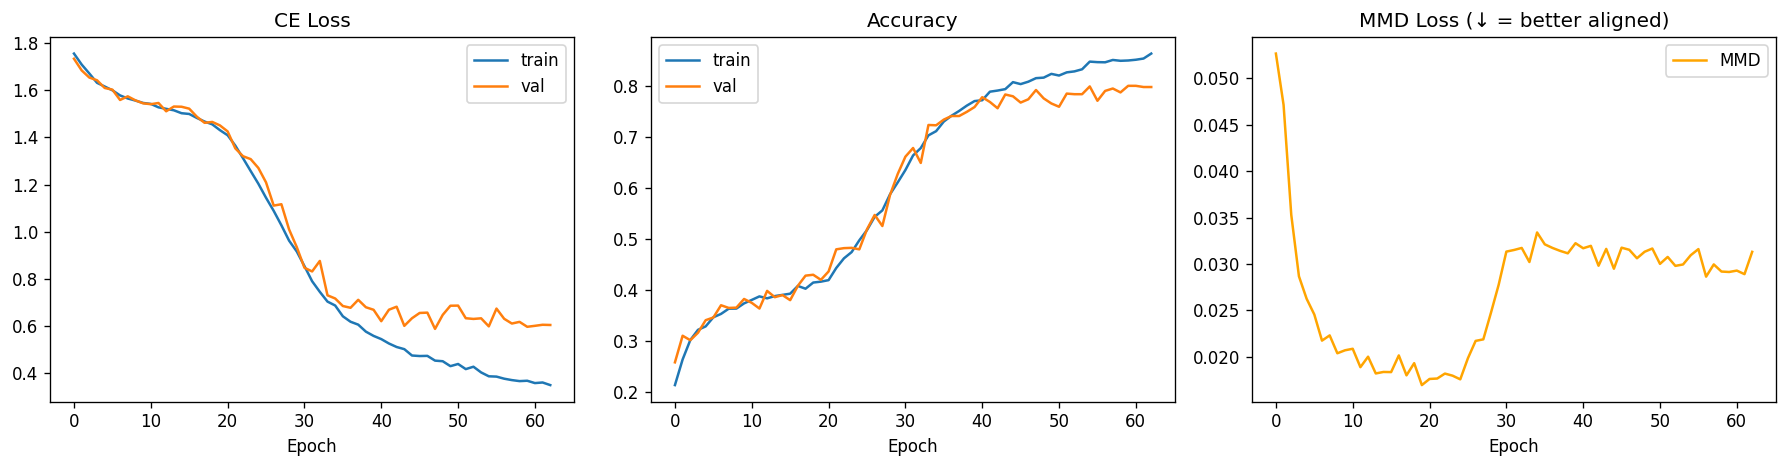

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history.history['ce_loss'],     label='train')
axes[0].plot(history.history['val_ce_loss'], label='val')
axes[0].set_title('CE Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(history.history['mmd_loss'], color='orange', label='MMD')
axes[2].set_title('MMD Loss (↓ = better aligned)'); axes[2].set_xlabel('Epoch'); axes[2].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_curves.png', bbox_inches='tight')
plt.show()

## 7. Source Test Evaluation

In [9]:
y_pred_src = np.argmax(model.predict(X_test, batch_size=BATCH_SIZE), axis=1)
src_f1 = f1_score(y_test, y_pred_src, average='macro')
print(f'Source Test Macro F1: {src_f1:.4f}')
print(classification_report(y_test, y_pred_src, target_names=class_names))

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step
Source Test Macro F1: 0.7723
              precision    recall  f1-score   support

    Effector       0.92      0.87      0.90       482
   Exhausted       0.74      0.89      0.81       166
       Naive       0.71      0.73      0.72       224
   Other_CD4       0.67      0.60      0.63       321
    Th1-like       0.71      0.74      0.72       141
        Treg       0.85      0.87      0.86       372

    accuracy                           0.79      1706
   macro avg       0.76      0.78      0.77      1706
weighted avg       0.79      0.79      0.79      1706



## 8. Target Domain Evaluation

In [10]:
y_pred_tgt = np.argmax(model.predict(X_target_eval, batch_size=BATCH_SIZE), axis=1)
tgt_f1 = f1_score(y_target_eval, y_pred_tgt, average='macro')
print(f'Target Domain Macro F1: {tgt_f1:.4f}')
print(classification_report(y_target_eval, y_pred_tgt, target_names=class_names))

100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step
Target Domain Macro F1: 0.3835
              precision    recall  f1-score   support

    Effector       0.49      0.44      0.46      2839
   Exhausted       0.11      0.18      0.14       903
       Naive       0.83      0.49      0.62      3806
   Other_CD4       0.28      0.29      0.28      2127
    Th1-like       0.19      0.26      0.22      1031
        Treg       0.50      0.69      0.58      2070

    accuracy                           0.44     12776
   macro avg       0.40      0.39      0.38     12776
weighted avg       0.51      0.44      0.46     12776



## 9. Confusion Matrices

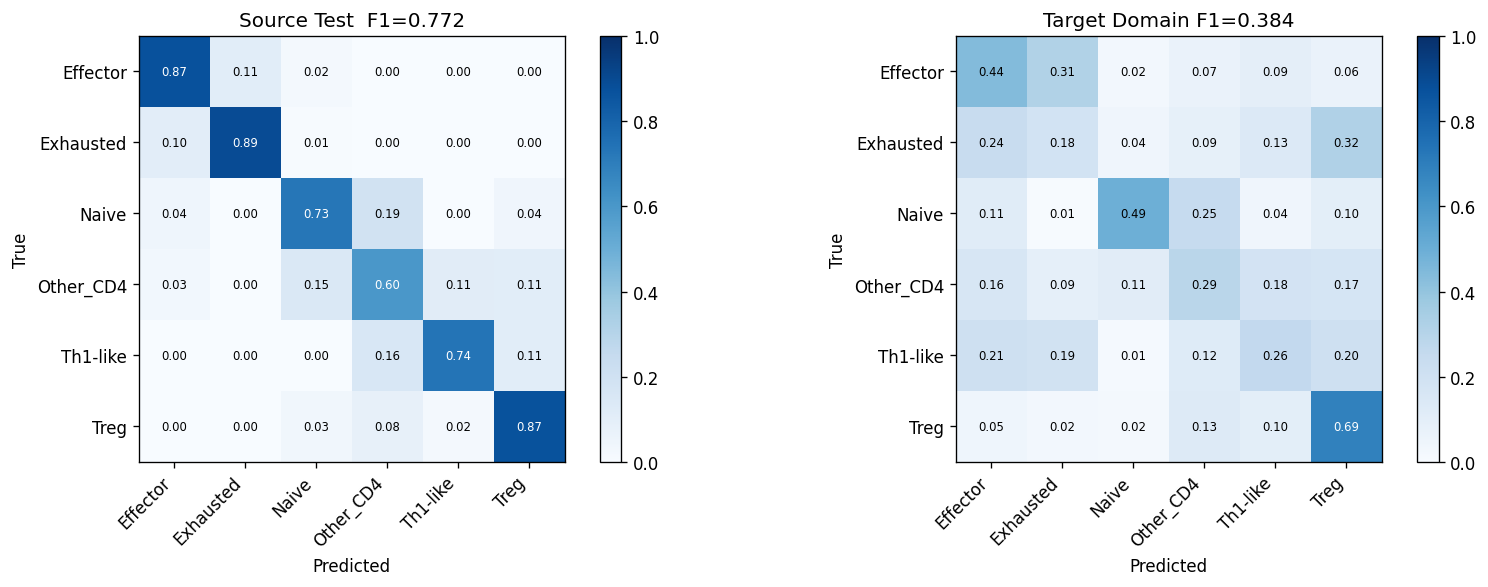

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_true, y_pred, title in [
    (axes[0], y_test,        y_pred_src, f'Source Test  F1={src_f1:.3f}'),
    (axes[1], y_target_eval, y_pred_tgt, f'Target Domain F1={tgt_f1:.3f}'),
]:
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xticks(range(n_classes)); ax.set_yticks(range(n_classes))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticklabels(class_names)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for i in range(n_classes):
        for j in range(n_classes):
            ax.text(j, i, f'{cm[i,j]:.2f}', ha='center', va='center',
                    color='white' if cm[i,j] > 0.5 else 'black', fontsize=7)
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrices.png', bbox_inches='tight')
plt.show()

## 10. Full Comparison Table + Save

In [12]:
src_report = classification_report(y_test,        y_pred_src, target_names=class_names, output_dict=True)
tgt_report = classification_report(y_target_eval, y_pred_tgt, target_names=class_names, output_dict=True)

results = {
    'model': 'PatchTransformerMMD',
    'config': {
        'patch_size': PATCH_SIZE, 'n_tokens': n_genes // PATCH_SIZE,
        'embedding_dim': EMBEDDING_DIM, 'num_heads': NUM_HEADS,
        'encoder_dim': ENCODER_DIM, 'dropout': DROPOUT,
        'mmd_weight': MMD_WEIGHT, 'learning_rate': LEARNING_RATE,
        'batch_size': BATCH_SIZE, 'epochs_trained': len(history.history['ce_loss']),
        'coral_aligned': True, 'class_weighted': True,
    },
    'source_test': {
        'macro_f1': src_f1,
        'accuracy': accuracy_score(y_test, y_pred_src),
        'per_class_f1': {cls: src_report[cls]['f1-score'] for cls in class_names},
    },
    'target_eval': {
        'macro_f1': tgt_f1,
        'accuracy': accuracy_score(y_target_eval, y_pred_tgt),
        'per_class_f1': {cls: tgt_report[cls]['f1-score'] for cls in class_names},
        'n_eval_cells': int(y_target_eval.shape[0]),
    },
}
with open(RESULTS_DIR / 'transformer_results.json', 'w') as f:
    json.dump(results, f, indent=2)

model.save_weights(str(RESULTS_DIR / 'transformer_weights.weights.h5'))

all_models = [
    ('LogReg',                   0.885, None),
    ('MLP',                      0.884, None),
    ('MMD-Net',                  None,  0.194),
    ('DANN v1',                  0.852, 0.391),
    ('DANN v2',                  0.875, 0.395),
    ('GeneAtt v1 (no align)',    0.894, 0.079),
    ('GeneAtt v2 (CORAL+MMD)',   0.893, 0.404),
    ('PatchTransformer (CORAL+MMD)', src_f1, tgt_f1),
]

print(f'\n{"Model":32s} {"Source F1":>10s} {"Target F1":>10s}')
print('-' * 56)
for name, sf, tf_ in all_models:
    s = f'{sf:.3f}' if sf is not None else '   —  '
    t = f'{tf_:.3f}' if tf_ is not None else '   —  '
    marker = ' ◄ best' if tf_ == tgt_f1 and tf_ is not None and tf_ >= 0.404 else ''
    print(f'{name:32s} {s:>10s} {t:>10s}{marker}')


Model                             Source F1  Target F1
--------------------------------------------------------
LogReg                                0.885        —  
MLP                                   0.884        —  
MMD-Net                                 —        0.194
DANN v1                               0.852      0.391
DANN v2                               0.875      0.395
GeneAtt v1 (no align)                 0.894      0.079
GeneAtt v2 (CORAL+MMD)                0.893      0.404
PatchTransformer (CORAL+MMD)          0.772      0.384
